# Project PV Power Forecasting

Your tasks is to create a PV production forecast for the _am Aawasser_ site in Buochs.

<br>

## Project Goal
The goal is to do a **"Day-Ahead-Forecast"** of the **PV Power** of the next 24 hours of the of the Aawasser site.


## Deliverable of this Project
The deliverables of this project are as follows:
* A **report** (in PDF Form)
* A 20min  **presentation**


<br>

### Contents of Report and Presentation
Within your report and presentation **describe your decisions** that went into your
* data preprocessing
* model architecture
* model training
* model optimization
  * training & test loss analysis
  * prediction plots analysis

<br>

## Focus of the Project
The Focus of your project should **NOT** be set on delivering the best possible predictor, but **to understand the steps needed** to create a working predictor. Therefore the **Solution Method** is of much greater importance than the actual result.





# Data

For your forecasting task, you recieve **3 Datasets** from the swiss local energy community **"Am Aawasser" located in Buochs**.

<br>

<div align="center"> <img src ='https://www.architektur3.ch/fileadmin/_processed_/4/a/csm_2020_MFH_Aawasser_Buochs-00005_6ee799bf17.jpg' alt="Aawasser Buochs"  height = "400"></div>

<br>

Namely you will receice these 3 datasets:


**Electric Load Dataset**:

* Source: [Download Link](https://drive.google.com/file/d/1QHlgXiD02ICcwG8Y7ePgyWRqqaDULlhg/view?usp=sharing)


* Contents:
  - House 1
  - House 2
  - House 3
  - Sum of all 3 Houses
  * `pandas` DataFrames saved as `.csv` files
    - readable with `pd.read_csv()`
  * Load Aggregate of all inhabitants of a house
  * 12 Months of Data (2022)
  * **Power readings in `[kW]`**
  * **15 min Measurement Interval**

**PV Dataset**:

- Source: [Download Link](https://drive.google.com/file/d/10m7AJ3fuJDV5b9ajjorKBaiHACImXazW/view?usp=sharing)
- Content:
  - PV Data of the Aawasser Solar Array
  * `pandas` DataFrames saved as `.csv` files
    - readable with `pd.read_csv()`
  * 12 Months of Data (2022)
  - **Power readings in `[kW]`**
  - **15 min Intervall**


**Weather Dataset**

- Source [Download Link](https://drive.google.com/file/d/1fHiummdk-gvYSPVCfzI1-nIYJQYNlI_P/view?usp=sharing)
- Content:
  - Meteo Blue Data from Horw (close enough to Aawasser)
  - 12 Months Historic Weather
  - **Hourly  Measurement Interval**
  - Offers the following **Measurements:**

<br>

<div align="center"> <img src ='https://drive.google.com/uc?id=1_rLmK7i7BKddMdvHuuB4mqz8_0fcZr1k' alt="Forecast" height="180" ></div>

<br>



## Utilisation of Data

You are free to choose **any / all** of these data sources for your forecasting task. When selecting the different data sources, think about what would make **sense for your forecasting task**, as to reason your selection.





# Before you Begin

**Talk with your Group members about a plan for your project task**

- What needs to be done?
  - What model type you want to choose?
  - What input data you want to give the model?
    - You can choose any model type for your predictor
- How do you want to **split the identified work**?

<br>

Also when you are working on these "work packages", think about **why** you doing the things you are implementing:
- Try to **reason your decisions.**



<br>


# Project Skeleton

What follows are a few sections outlining your data science / AI tasks which lay ahead.

<br>

Additionnally you are allowed to use any of the scripts / slides / instructions you received during this course.

<br>

Furthermore, if you need any further guidance / help, you can consult your project expert.




## Upload the Data to this script
After **downloading the data** using the given links, you need to **upload the data to this script**, using the following code snippet:

In [ ]:
# Code to read csv Files
from google.colab import files

# select all wanted csv here
uploaded = files.upload()


Saving Load_2022_clean.csv to Load_2022_clean.csv
Saving PV_2022_clean.csv to PV_2022_clean.csv
Saving Weather_clean_NEMS.csv to Weather_clean_NEMS.csv


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


df_load = pd.read_csv("Load_2022_clean.csv")
df_pv = pd.read_csv("PV_2022_clean.csv")
df_weather = pd.read_csv("Weather_clean_NEMS.csv")

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## Preprocessing

Preprocess the Aawasser Load Data

* do a **classic preprocessing** of the load data
* create a set of time-series-datasets usable by the `model.fit() ` function
  - what is your **input_window**
  - what is your **output_window**

* document and **reason** your steps




## Data Analysis

**Plot samples** of the load data to **understand**:
- what you are "feeding" the model during training
- what the model is "targeting"

### Data Analysis for PV

# Data Preprocessing Pipeline

In [ ]:
df_pv.head()

,TimestampInUtc,PV
0,2021-12-31 23:00,0.0
1,2021-12-31 23:15,0.0
2,2021-12-31 23:30,0.0
3,2021-12-31 23:45,0.0
4,2022-01-01 00:00,0.0


In [ ]:
df_pv.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 35036 entries, 0 to 35035
Data columns (total 2 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   TimestampInUtc  35036 non-null  object 
 1   PV              35035 non-null  float64
dtypes: float64(1), object(1)
memory usage: 547.6+ KB


In [ ]:
df_weather.head()

,timestamp,Temperature,Sunshine Duration,Shortwave Radiation,Direct Shortwave Radiation,Diffuse Shortwave Radiation,Snowfall Amount,Relative Humidity,Cloud Cover Total
0,2022-01-01 00:00:00,9.657269,0.0,0.0,0.0,0.0,0.0,29.0,0.0
1,2022-01-01 01:00:00,9.457270,0.0,0.0,0.0,0.0,0.0,29.0,0.0
2,2022-01-01 02:00:00,9.787270,0.0,0.0,0.0,0.0,0.0,28.0,0.0
3,2022-01-01 03:00:00,9.467270,0.0,0.0,0.0,0.0,0.0,28.0,0.0
4,2022-01-01 04:00:00,8.797270,0.0,0.0,0.0,0.0,0.0,30.0,0.0


In [ ]:
df_weather.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8760 entries, 0 to 8759
Data columns (total 9 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   timestamp                    8760 non-null   object 
 1   Temperature                  8760 non-null   float64
 2   Sunshine Duration            8760 non-null   float64
 3   Shortwave Radiation          8760 non-null   float64
 4   Direct Shortwave Radiation   8760 non-null   float64
 5   Diffuse Shortwave Radiation  8760 non-null   float64
 6   Snowfall Amount              8760 non-null   float64
 7   Relative Humidity            8760 non-null   float64
 8   Cloud Cover Total            8760 non-null   float64
dtypes: float64(8), object(1)
memory usage: 616.1+ KB


### Drop NaN

In [ ]:
# Drop NaN
print("NaN Summary:")
print(df_pv.isna().sum())
# Count per column
print(f"\nTotal NaNs: {df_pv.isna().sum().sum()}")
print("\nRows with NaNs:")
print(df_pv[df_pv.isna().any(axis=1)].index.tolist())

NaN Summary:
TimestampInUtc    0
PV                1
dtype: int64

Total NaNs: 1

Rows with NaNs:
[12387]


In [ ]:
# linear bad choice?

df_load.interpolate(method='linear', inplace=True)

/tmp/ipython-input-3523045876.py:3: FutureWarning: DataFrame.interpolate with object dtype is deprecated and will raise in a future version. Call obj.infer_objects(copy=False) before interpolating instead.
  df_load.interpolate(method='linear', inplace=True)


## Timestamp into Datetime

In [ ]:
df_weather["timestamp"] = pd.to_datetime(df_weather["timestamp"])

df_weather["timestamp"] = (
    df_weather["timestamp"]
      .dt.tz_localize("Europe/Zurich", ambiguous="NaT", nonexistent="shift_forward")
      .dt.tz_convert("UTC")
)


In [ ]:
df_pv["TimestampInUtc"] = pd.to_datetime(df_pv["TimestampInUtc"])
df_pv["TimestampInUtc"] = df_pv["TimestampInUtc"].dt.tz_localize("UTC")


In [ ]:
df_pv.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 35036 entries, 0 to 35035
Data columns (total 2 columns):
 #   Column          Non-Null Count  Dtype              
---  ------          --------------  -----              
 0   TimestampInUtc  35036 non-null  datetime64[ns, UTC]
 1   PV              35035 non-null  float64            
dtypes: datetime64[ns, UTC](1), float64(1)
memory usage: 547.6 KB


In [ ]:
df_weather.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8760 entries, 0 to 8759
Data columns (total 9 columns):
 #   Column                       Non-Null Count  Dtype              
---  ------                       --------------  -----              
 0   timestamp                    8759 non-null   datetime64[ns, UTC]
 1   Temperature                  8760 non-null   float64            
 2   Sunshine Duration            8760 non-null   float64            
 3   Shortwave Radiation          8760 non-null   float64            
 4   Direct Shortwave Radiation   8760 non-null   float64            
 5   Diffuse Shortwave Radiation  8760 non-null   float64            
 6   Snowfall Amount              8760 non-null   float64            
 7   Relative Humidity            8760 non-null   float64            
 8   Cloud Cover Total            8760 non-null   float64            
dtypes: datetime64[ns, UTC](1), float64(8)
memory usage: 616.1 KB


## Outliers

In [ ]:
def clean_pv_using_delta(df, column_to_clean='PV', threshold=5):
    df_copy = df.copy()
    delta = df[column_to_clean].diff()

    for i in range(1, len(delta)):
        if (abs(delta.iloc[i]) > threshold) and (abs(delta.iloc[i+1])>threshold):
            df_copy[column_to_clean].iloc[i] = np.nan

    df_copy.loc[df_copy.index[i], column_to_clean] = np.nan
    #df_copy = df_copy.interpolate(method='linear', inplace=True)
     #df[f'{pv_col}_clean'] = df_clean.ffill().bfill()

    return df_copy

In [ ]:
clean_pv_using_delta(df_pv,'PV', 5)

Maximum PV: 96.87855555556598
Occurred at: 14258


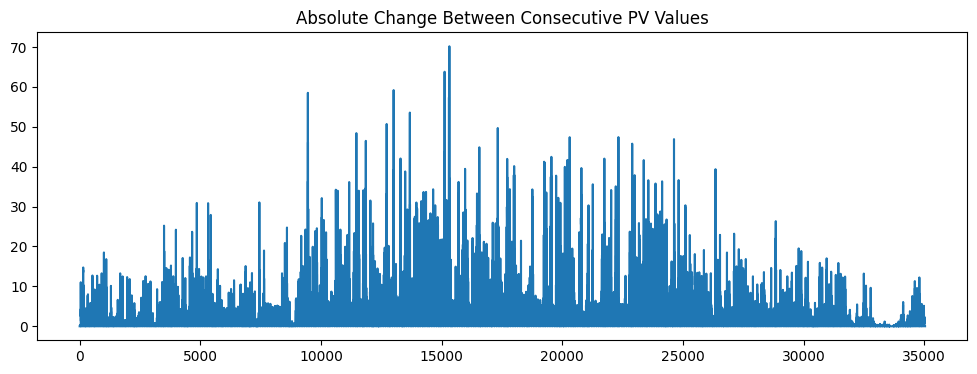

Sudden spike events: 351


96.87855555556598

In [ ]:
#checking for outliers in the PV dataset

# max value generated and when was this
max_value = df_pv["PV"].max()
max_time = df_pv["PV"].idxmax()

print("Maximum PV:", max_value)
print("Occurred at:", max_time)

# outliers in terms of abnormal jumps by getting the delta
df_pv["PV_diff"] = df_pv["PV"].diff().abs()

df_pv["PV_diff"].plot(figsize=(12,4))
plt.title("Absolute Change Between Consecutive PV Values")
plt.show()

# now we can see the jump
threshold = df_pv["PV_diff"].quantile(0.99)
jump_outliers = df_pv[df_pv["PV_diff"] > threshold]

print("Sudden spike events:", len(jump_outliers))

df_pv["PV"].describe()

df_pv["PV"].max()

## Cos Sin
DayOfYear sagt dem Modell: "Wir befinden uns im Winter / Sommer-Bereich des Jahres"

In [ ]:
df_weather['hour'] = df_weather['timestamp'].dt.hour          # 0-23
#df_weather['weekday'] = df_weather['timestamp'].dt.weekday    # 0=Monday to 6=Sunday
#df_weather['day'] = df_weather['timestamp'].dt.day
#df_weather['weekday']

# Hours (cycle every 24)
df_weather['Hour_sin'] = np.sin(2 * np.pi * df_weather['hour'] / 24)
df_weather['Hour_cos'] = np.cos(2 * np.pi * df_weather['hour'] / 24)

# jahreskreis kontinuierlich (jahreverlauf zyklus wegen der Saisons, also welche Saison gerade?)
df_weather["dayofyear"] = df_weather["timestamp"].dt.dayofyear
df_weather["Day_sin"] = np.sin(2 * np.pi * df_weather["dayofyear"] / 365)
df_weather["Day_cos"] = np.cos(2 * np.pi * df_weather["dayofyear"] / 365)

# Weekdays (cycle every 7)
# df_weather['Weekday_sin'] = np.sin(2 * np.pi * df_weather['weekday'] / 7)
# df_weather['Weekday_cos'] = np.cos(2 * np.pi * df_weather['weekday'] / 7)

# Day of month (cycle every 31, handles 31→1 proximity)
#df_weather['Day_sin'] = np.sin(2 * np.pi * df_weather['day'] / 31)
#df_weather['Day_cos'] = np.cos(2 * np.pi * df_weather['day'] / 31)

In [ ]:
df_weather.head()

,timestamp,Temperature,Sunshine Duration,Shortwave Radiation,Direct Shortwave Radiation,Diffuse Shortwave Radiation,Snowfall Amount,Relative Humidity,Cloud Cover Total,hour,Hour_sin,Hour_cos,dayofyear,Day_sin,Day_cos
0,2021-12-31 23:00:00+00:00,9.657269,0.0,0.0,0.0,0.0,0.0,29.0,0.0,23.0,-0.258819,0.965926,365.0,6.432491e-16,1.000000
1,2022-01-01 00:00:00+00:00,9.457270,0.0,0.0,0.0,0.0,0.0,29.0,0.0,0.0,0.000000,1.000000,1.0,1.721336e-02,0.999852
2,2022-01-01 01:00:00+00:00,9.787270,0.0,0.0,0.0,0.0,0.0,28.0,0.0,1.0,0.258819,0.965926,1.0,1.721336e-02,0.999852
3,2022-01-01 02:00:00+00:00,9.467270,0.0,0.0,0.0,0.0,0.0,28.0,0.0,2.0,0.500000,0.866025,1.0,1.721336e-02,0.999852
4,2022-01-01 03:00:00+00:00,8.797270,0.0,0.0,0.0,0.0,0.0,30.0,0.0,3.0,0.707107,0.707107,1.0,1.721336e-02,0.999852


In [ ]:
df_weather.set_index("timestamp", inplace=True)
df_weather.sort_index(inplace=True)

### PV from 15 minutes to an hour with sum and median
The PV data is given in 15-minute intervals. Since the weather data is hourly and the forecasting task is day-ahead (24 hours), the PV data was resampled to hourly resolution using the mean. Because PV values are given in kW (power), the hourly mean represents the average power within each hour.

In [ ]:
df_pv = df_pv.sort_values("TimestampInUtc")
df_pv["PV"] = df_pv["PV"].clip(lower=0)

df_pv_hourly = (
    df_pv.set_index("TimestampInUtc")["PV"]
        .resample("H")
        .mean()
        .to_frame()
)

/tmp/ipython-input-1295568914.py:6: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  .resample("H")


In [ ]:
df_pv_hourly.sort_index(inplace=True)

## Remove highly correlated features
ok to drop one, write the script so we can activate one or the other

In [ ]:
USE_GLOBAL = True
USE_DIRECT = True
USE_DIFFUSE = False

radiation_features = []
if USE_GLOBAL:
    radiation_features.append("Shortwave Radiation")
if USE_DIRECT:
    radiation_features.append("Direct Shortwave Radiation")
if USE_DIFFUSE:
    radiation_features.append("Diffuse Shortwave Radiation")

base_features = [
    "Temperature",
    "Cloud Cover Total",
    "Relative Humidity",
    "Sunshine Duration",
    "Snowfall Amount",
    "Hour_sin",
    "Hour_cos",
    "Day_sin",
    "Day_cos",
]

selected_features = base_features + radiation_features
df_weather_selected = df_weather[selected_features]

### Merge PV + weather (hourly aligned)

In [ ]:
df_day = df_pv_hourly.join(df_weather_selected, how="inner")
df_day.dropna(inplace=True)

print("\nMerged df_day head:")
print(df_day.head())
print("\nMerged df_day shape:", df_day.shape)


Merged df_day head:
                            PV  Temperature  Cloud Cover Total  \
TimestampInUtc                                                   
2021-12-31 23:00:00+00:00  0.0     9.657269                0.0   
2022-01-01 00:00:00+00:00  0.0     9.457270                0.0   
2022-01-01 01:00:00+00:00  0.0     9.787270                0.0   
2022-01-01 02:00:00+00:00  0.0     9.467270                0.0   
2022-01-01 03:00:00+00:00  0.0     8.797270                0.0   

                           Relative Humidity  Sunshine Duration  \
TimestampInUtc                                                    
2021-12-31 23:00:00+00:00               29.0                0.0   
2022-01-01 00:00:00+00:00               29.0                0.0   
2022-01-01 01:00:00+00:00               28.0                0.0   
2022-01-01 02:00:00+00:00               28.0                0.0   
2022-01-01 03:00:00+00:00               30.0                0.0   

                           Snowfall Amount  Ho



```
# Als Code formatiert
```

##  Model Creation

Create a **ML model** for the **day-ahead-forecast** of the electric load.

* create the Model
  * document the reasoning behind your model architecure
* plot its summary
* compile the model
  * select a loss function
* document your finidings

### Windowing

In [ ]:
def split_season_stratified(df):
    df = df.sort_index()

    months = df.index.month
    days = df.index.day

    train_months = [1, 2, 4, 5, 7, 8, 10, 11]
    vt_months = [3, 6, 9, 12]

    train_df = df[months.isin(train_months)].copy()
    val_df = df[(months.isin(vt_months)) & (days <= 15)].copy()
    test_df = df[(months.isin(vt_months)) & (days > 15)].copy()

    return train_df, val_df, test_df

Windowing needs to be gap safe

In [ ]:
def create_windows_no_gaps(df, feature_cols, target_col="PV",
                           input_window=168, output_window=24,
                           stride=6):

    df = df.sort_index()

    # PV history + weather + time features
    X_vals = df[feature_cols].values
    # only PV
    y_vals = df[target_col].values
    idx = df.index

    X_list, y_list = [], []

    for end in range(input_window, len(df) - output_window + 1, stride):

        start = end - input_window
        out_end = end + output_window

        window_index = idx[start:out_end]

        # Check hourly continuity
        deltas = np.diff(window_index.values.astype("datetime64[h]").astype(np.int64))
        if np.any(deltas != 1):
            continue

        X_list.append(X_vals[start:end])
        y_list.append(y_vals[end:out_end])

    return np.array(X_list), np.array(y_list)


In [ ]:
feature_cols = ["PV"] + selected_features

In [ ]:
train_df, val_df, test_df = split_season_stratified(df_day)

LOOKBACK = 168   # 7 Tage
HORIZON = 24     # 24h

X_train, y_train = create_windows_no_gaps(train_df, feature_cols, "PV", LOOKBACK, HORIZON)
X_val, y_val = create_windows_no_gaps(val_df, feature_cols, "PV", LOOKBACK, HORIZON)
X_test, y_test = create_windows_no_gaps(test_df, feature_cols, "PV", LOOKBACK, HORIZON)

print("Train:", X_train.shape, y_train.shape)
print("Val:", X_val.shape, y_val.shape)
print("Test:", X_test.shape, y_test.shape)


Train: (816, 168, 12) (816, 24)
Val: (116, 168, 12) (116, 24)
Test: (100, 168, 12) (100, 24)


In [ ]:
print("NaNs in df_day:", df_day.isna().sum().sum())
print("X_train NaNs:", np.isnan(X_train).sum(), "y_train NaNs:", np.isnan(y_train).sum())
print("Last train timestamp:", train_df.index.max())
print("First val timestamp:", val_df.index.min())


NaNs in df_day: 0
X_train NaNs: 0 y_train NaNs: 0
Last train timestamp: 2022-11-30 23:00:00+00:00
First val timestamp: 2022-03-01 00:00:00+00:00


### Scaling
Because Scaler only understands (nr_samples, features)
X_train ist 3D-Tensor (samples, 168, features)
1. zu 2D flatten (samples*168, features)
2. Scaler nur auf train fitten
3. Train/Val/Test transformieren
4. Wieder zurüc zu 3D shapen

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

# flatten train to (N*168, F)
N_train, T, F = X_train.shape
X_train_2d = X_train.reshape(-1, F)

scaler.fit(X_train_2d)

X_train_scaled = scaler.transform(X_train_2d).reshape(N_train, T, F)

# val
N_val = X_val.shape[0]
X_val_scaled = scaler.transform(X_val.reshape(-1, F)).reshape(N_val, T, F)

# test
N_test = X_test.shape[0]
X_test_scaled = scaler.transform(X_test.reshape(-1, F)).reshape(N_test, T, F)

### Baseline Model

In [ ]:
from tensorflow import keras
from keras.models import Sequential
from keras.layers import Dense,Input


##Baseline

## Model Training

Train the Model on a subset of data


In [ ]:
import os, json, time
from pathlib import Path
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import TensorDataset, DataLoader
from copy import deepcopy

In [ ]:
PROJECT_DIR = "/content/drive/MyDrive/forecast_project_final"
RUNS_DIR = os.path.join(PROJECT_DIR, "runs_gru")
Path(RUNS_DIR).mkdir(parents=True, exist_ok=True)
print("Saving to:", RUNS_DIR)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

Saving to: /content/drive/MyDrive/forecast_project_final/runs_gru
Device: cpu


In [ ]:
import torch
import torch.nn as nn

class GRUForecast(nn.Module):
    def __init__(self, input_size, hidden_size=64, num_layers=1, dropout=0.0):
        super(GRUForecast, self).__init__()

        self.gru = nn.GRU(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0.0
        )

        self.fc = nn.Linear(hidden_size, 24)  # 24h forecast

    def forward(self, x):
        # x shape: (batch_size, 168, features)
        out, _ = self.gru(x)

        last_hidden = out[:, -1, :]  # shape: (batch_size, hidden_size)

        output = self.fc(last_hidden)  # shape: (batch_size, 24)

        return output


### Explanation of print

In [ ]:
input_size = X_train.shape[2]  # number of features
model = GRUForecast(
    input_size=input_size,
    hidden_size=64,
    num_layers=1,
    dropout=0.0
)

print(model)

GRUForecast(
  (gru): GRU(12, 64, batch_first=True)
  (fc): Linear(in_features=64, out_features=24, bias=True)
)


### Training Setup

In [ ]:
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import TensorDataset, DataLoader
from copy import deepcopy
import matplotlib.pyplot as plt
import random

In [ ]:
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

Device: cpu


### Metrics SOTA

In [ ]:
def mae(pred, true):
    return torch.mean(torch.abs(pred - true))

def mse(pred, true):
    return torch.mean((pred - true) ** 2)

def mape_safe(pred, true, eps=1e-3):
    denom = torch.clamp(torch.abs(true), min=eps)
    return torch.mean(torch.abs((pred - true) / denom)) * 100.0

### Early Stopping

In [ ]:
class EarlyStopping:
    def __init__(self, patience=50, min_delta=0.0):
        self.patience = patience
        self.min_delta = min_delta
        self.best = None
        self.counter = 0

    def step(self, value):
        if self.best is None or value < self.best - self.min_delta:
            self.best = value
            self.counter = 0
            return False
        self.counter += 1
        return self.counter >= self.patience

### Create DataLoaders
With shuffle only for training samples (only shuffling samples not within)
- TensorDataset:

In [ ]:
from torch.utils.data import TensorDataset, DataLoader
import torch

def make_loader(X, y, batch_size=64, shuffle=False):
    """
    Creates a DataLoader for given numpy arrays.

    X: shape (N, 168, F)
    y: shape (N, 24)
    """
    dataset = TensorDataset(
        torch.tensor(X, dtype=torch.float32),
        torch.tensor(y, dtype=torch.float32)
    )

    return DataLoader(dataset, batch_size=batch_size, shuffle=shuffle)


In [ ]:
def run_one_epoch(model, loader, loss_fn, optimizer=None):
    is_train = optimizer is not None
    model.train() if is_train else model.eval()

    losses, mses, maes, mapes = [], [], [], []

    for Xb, yb in loader:
        Xb, yb = Xb.to(device), yb.to(device)

        if is_train:
            optimizer.zero_grad()

        with torch.set_grad_enabled(is_train):
            pred = model(Xb)               # (batch, 24)
            loss = loss_fn(pred, yb)       # Huber loss

            if is_train:
                loss.backward()
                torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
                optimizer.step()

        losses.append(loss.detach())
        mses.append(mse(pred, yb).detach())
        maes.append(mae(pred, yb).detach())
        mapes.append(mape_safe(pred, yb).detach())

    # return epoch means
    return (
        float(torch.stack(losses).mean().cpu()),
        float(torch.stack(mses).mean().cpu()),
        float(torch.stack(maes).mean().cpu()),
        float(torch.stack(mapes).mean().cpu()),
    )


In [ ]:
def train_gru_run(config, X_train, y_train, X_val, y_val):
    train_loader = make_loader(
        X_train, y_train,
        batch_size=config["batch_size"],
        shuffle=True   # train darf geshuffelt werden
    )

    val_loader = make_loader(
        X_val, y_val,
        batch_size=config["batch_size"],
        shuffle=False  # val niemals shufflen
    )

    model = GRUForecast(
        input_size=X_train.shape[2],
        hidden_size=config["hidden_size"],
        num_layers=config["num_layers"],
        dropout=config["dropout"]
    ).to(device)

    # Huber Loss -> best of both worlds (SmoothL1)
    loss_fn = nn.SmoothL1Loss(beta=config["huber_beta"])

    optimizer = torch.optim.Adam(
        model.parameters(),
        lr=config["lr"],
        weight_decay=config["weight_decay"]
    )

    # reduce LR if val loss doesn't improve
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer,
        mode="min",
        factor=config["lr_factor"],
        patience=config["lr_patience"],
        min_lr=config["min_lr"]
    )

    early = EarlyStopping(patience=config["early_patience"], min_delta=config["min_delta"])

    history = {
        "train_loss": [], "val_loss": [],
        "train_mse": [],  "val_mse": [],
        "train_mae": [],  "val_mae": [],
        "train_mape": [], "val_mape": [],
        "lr": []
    }

    best_state = deepcopy(model.state_dict())  # initial
    best_val = float("inf")

    for epoch in range(config["epochs"]):
        tr_loss, tr_mse, tr_mae, tr_mape = run_one_epoch(model, train_loader, loss_fn, optimizer)
        va_loss, va_mse, va_mae, va_mape = run_one_epoch(model, val_loader, loss_fn, optimizer=None)

        scheduler.step(va_loss)
        current_lr = optimizer.param_groups[0]["lr"]

        history["train_loss"].append(tr_loss)
        history["val_loss"].append(va_loss)
        history["train_mse"].append(tr_mse)
        history["val_mse"].append(va_mse)
        history["train_mae"].append(tr_mae)
        history["val_mae"].append(va_mae)
        history["train_mape"].append(tr_mape)
        history["val_mape"].append(va_mape)
        history["lr"].append(current_lr)

        if (epoch+1) % 5 == 0:
          print(f"Epoch {epoch+1}: train_loss={tr_loss:.4f}, val_loss={va_loss:.4f}, lr={current_lr:.2e}")

        # keep best model by val_loss
        if va_loss < best_val:
            best_val = va_loss
            best_state = deepcopy(model.state_dict())

        # early stopping
        if early.step(va_loss):
            break

    # load best
    model.load_state_dict(best_state)

    run_out = {
        "config": config,
        "history": history,
        "best_val_loss": float(best_val),
        "state_dict": deepcopy(model.state_dict()),
        "epochs_ran": len(history["val_loss"]),
    }
    return run_out


### Save helpers

In [ ]:
def hp_to_run_name(hp, i):
    return (
        f"run_{i:03d}"
        f"_lr{hp['lr']:.0e}"
        f"_hs{hp['hidden_size']}"
        f"_nl{hp['num_layers']}"
        f"_do{hp['dropout']}"
        f"_wd{hp['weight_decay']:.0e}"
        f"_hb{hp['huber_beta']}"
    ).replace("+", "")

def save_run(run_out, run_dir):
    os.makedirs(run_dir, exist_ok=True)

    # model
    torch.save(run_out["state_dict"], os.path.join(run_dir, "model_best.pt"))

    # jsons
    with open(os.path.join(run_dir, "config.json"), "w") as f:
        json.dump(run_out["config"], f, indent=2)

    with open(os.path.join(run_dir, "history.json"), "w") as f:
        json.dump(run_out["history"], f, indent=2)

    last_train = run_out["history"]["train_loss"][-1] if run_out["history"]["train_loss"] else None
    last_val   = run_out["history"]["val_loss"][-1] if run_out["history"]["val_loss"] else None

    summary = {
      "best_val_loss": run_out["best_val_loss"],
      "epochs_ran": run_out["epochs_ran"],
      "last_train_loss": last_train,
      "last_val_loss": last_val,
    }
    with open(os.path.join(run_dir, "summary.json"), "w") as f:
        json.dump(summary, f, indent=2)

### Hyperparameter Search

In [ ]:
from itertools import product
import joblib

# 0) Save experiment-level artifacts once
joblib.dump(scaler, os.path.join(RUNS_DIR, "scaler.joblib"))
with open(os.path.join(RUNS_DIR, "feature_cols.json"), "w") as f:
    json.dump(feature_cols, f, indent=2)

split_info = {
    "LOOKBACK": LOOKBACK,
    "HORIZON": HORIZON,
    "stride": 1,
    "X_train_shape": list(X_train.shape),
    "X_val_shape": list(X_val.shape),
    "X_test_shape": list(X_test.shape),
    "train_months": [1,2,4,5,7,8,10,11],
    "vt_months": [3,6,9,12]
}
with open(os.path.join(RUNS_DIR, "split_info.json"), "w") as f:
    json.dump(split_info, f, indent=2)

grid = {
    "lr": [1e-3, 5e-4, 1e-4],
    "hidden_size":[32, 64, 128],
    "num_layers": [1, 2],
    "dropout": [0.0, 0.1, 0.2],
    "weight_decay": [0.0, 1e-4],
    "huber_beta": [0.5, 1.0]
}

base = {
    "batch_size": 64,
    "epochs": 400,
    "weight_decay": 0.0,
    "early_patience": 10,
    "min_delta": 1e-5,

    # Huber
    "huber_beta": 1.0,

    # scheduler
    "lr_factor": 0.5,
    "lr_patience": 3,
    "min_lr": 1e-6,
}

search_space = [
    {
        "lr": lr,
        "hidden_size": hs,
        "num_layers": nl,
        "dropout": do,
        "weight_decay": wd,
        "huber_beta": hb
    }
    for lr, hs, nl, do, wd, hb in product(
        grid["lr"],
        grid["hidden_size"],
        grid["num_layers"],
        grid["dropout"],
        grid["weight_decay"],
        grid["huber_beta"]
    )
    if not (nl == 1 and do > 0.0)  # dropout only works if num_layers > 1
]

print("Total runs:", len(search_space))

runs = []
index_rows = []
for i, hp in enumerate(search_space):
    cfg = {**base, **hp}
    run_name = hp_to_run_name(hp, i)
    run_dir = os.path.join(RUNS_DIR, run_name)

    print("\n=== RUN:", run_name, "===")
    out = train_gru_run(cfg, X_train_scaled, y_train, X_val_scaled, y_val)

    save_run(out, run_dir)

    runs.append(out)
    index_rows.append({
        "run_name": run_name,
        "run_dir": run_dir,
        "best_val_loss": out["best_val_loss"],
        "epochs_ran": out["epochs_ran"],
        **hp
    })

    print("Saved:", run_name, "| best_val_loss:", out["best_val_loss"])

df_index = pd.DataFrame(index_rows).sort_values("best_val_loss")
df_index.to_csv(os.path.join(RUNS_DIR, "runs_index.csv"), index=False)
print("\nSaved runs_index.csv")

best_run = min(runs, key=lambda r: r["best_val_loss"])
best_hp = best_run["config"]

best_name = (
    f"best_model_lr{best_hp['lr']:.0e}"
    f"_hs{best_hp['hidden_size']}"
    f"_nl{best_hp['num_layers']}"
    f"_do{best_hp['dropout']}"
    f"_wd{best_hp['weight_decay']:.0e}"
    f"_hb{best_hp['huber_beta']}"
).replace("+", "")

BEST_DIR = os.path.join(RUNS_DIR, "BEST")
os.makedirs(BEST_DIR, exist_ok=True)

torch.save(best_run["state_dict"], os.path.join(BEST_DIR, f"{best_name}.pt"))

with open(os.path.join(BEST_DIR, "best_config.json"), "w") as f:
    json.dump(best_run["config"], f, indent=2)

with open(os.path.join(BEST_DIR, "best_history.json"), "w") as f:
    json.dump(best_run["history"], f, indent=2)

with open(os.path.join(BEST_DIR, "best_summary.json"), "w") as f:
    json.dump({"best_val_loss": best_run["best_val_loss"], "epochs_ran": best_run["epochs_ran"]}, f, indent=2)

print("\nBEST:", best_name)
print("Best val loss:", best_run["best_val_loss"])
print("Saved BEST to:", BEST_DIR)


Die letzten 5000 Zeilen der Streamingausgabe wurden abgeschnitten.
Epoch 120: train_loss=7.4564, val_loss=7.2950, lr=5.00e-04
Epoch 125: train_loss=7.3085, val_loss=7.2087, lr=5.00e-04
Epoch 130: train_loss=7.1532, val_loss=7.1170, lr=5.00e-04
Epoch 135: train_loss=7.0588, val_loss=7.0114, lr=5.00e-04
Epoch 140: train_loss=6.9134, val_loss=6.9585, lr=5.00e-04
Epoch 145: train_loss=6.7888, val_loss=6.8405, lr=5.00e-04
Epoch 150: train_loss=6.6849, val_loss=6.8177, lr=5.00e-04
Epoch 155: train_loss=6.6043, val_loss=6.7512, lr=5.00e-04
Epoch 160: train_loss=6.5314, val_loss=6.6950, lr=5.00e-04
Epoch 165: train_loss=6.4159, val_loss=6.7187, lr=5.00e-04
Epoch 170: train_loss=6.3181, val_loss=6.4699, lr=2.50e-04
Epoch 175: train_loss=6.2910, val_loss=6.4800, lr=1.25e-04
Epoch 180: train_loss=6.2685, val_loss=6.4486, lr=1.25e-04
Epoch 185: train_loss=6.2497, val_loss=6.3806, lr=1.25e-04
Epoch 190: train_loss=6.2235, val_loss=6.4058, lr=1.25e-04
Epoch 195: train_loss=6.1718, val_loss=6.3913, l

### Testset Evaluation

In [ ]:
def mae_np(pred, true):
    return float(np.mean(np.abs(pred - true)))

def mse_np(pred, true):
    return float(np.mean((pred - true) ** 2))

def mape_np(pred, true, eps=1e-3):
    denom = np.maximum(np.abs(true), eps)
    return float(np.mean(np.abs((pred - true) / denom)) * 100.0)

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import os, glob, json, joblib
import numpy as np
import torch
import torch.nn as nn

RUNS_DIR = "/content/drive/MyDrive/forecast_project_final/runs_gru"
BEST_DIR = os.path.join(RUNS_DIR, "BEST")
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# scaler + feature order
scaler = joblib.load(os.path.join(RUNS_DIR, "scaler.joblib"))
with open(os.path.join(RUNS_DIR, "feature_cols.json"), "r") as f:
    feature_cols = json.load(f)

# best run config
with open(os.path.join(BEST_DIR, "best_config.json"), "r") as f:
    best_cfg = json.load(f)

# best model weights
pt_files = glob.glob(os.path.join(BEST_DIR, "best_model_*.pt"))
assert len(pt_files) == 1, f"Expected 1 best_model_*.pt, found {len(pt_files)}"
best_pt_path = pt_files[0]
print("Using best model:", os.path.basename(best_pt_path))


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Using best model: best_model_lr1e-03_hs128_nl1_do0.0_wd0e00_hb1.0.pt


In [ ]:
model = GRUForecast(
    input_size=len(feature_cols),
    hidden_size=best_cfg["hidden_size"],
    num_layers=best_cfg["num_layers"],
    dropout=best_cfg["dropout"]
).to(device)

state = torch.load(best_pt_path, map_location=device)
model.load_state_dict(state)
model.eval()
print("Model loaded.")

N, T, F = X_test.shape
assert F == len(feature_cols), f"Feature mismatch: X_test has {F}, feature_cols has {len(feature_cols)}"

X_test_scaled = scaler.transform(X_test.reshape(-1, F)).reshape(N, T, F)

with torch.no_grad():
    y_pred = model(torch.tensor(X_test_scaled, dtype=torch.float32).to(device)).cpu().numpy()

assert y_pred.shape == y_test.shape, f"Shape mismatch: pred {y_pred.shape}, true {y_test.shape}"

test_mae  = mae_np(y_pred, y_test)
test_mse  = mse_np(y_pred, y_test)
test_mape = mape_np(y_pred, y_test)

print("\nTEST RESULTS (Day-Ahead 24h):")
print("MAE :", test_mae)
print("MSE :", test_mse)
print("MAPE:", test_mape)

with open(os.path.join(BEST_DIR, "test_metrics.json"), "w") as f:
    json.dump({"test_mae": test_mae, "test_mse": test_mse, "test_mape": test_mape}, f, indent=2)

np.save(os.path.join(BEST_DIR, "y_pred_test.npy"), y_pred)
np.save(os.path.join(BEST_DIR, "y_true_test.npy"), y_test)

print("Saved test_metrics + predictions to:", BEST_DIR)

Model loaded.

TEST RESULTS (Day-Ahead 24h):
MAE : 6.871335725826049
MSE : 139.18258629357894
MAPE: 96578.35187901309
Saved test_metrics + predictions to: /content/drive/MyDrive/forecast_project_final/runs_gru/BEST


In [ ]:
preds = np.load(os.path.join(BEST_DIR, "y_pred_test.npy"))

In [ ]:
true_values = np.load(os.path.join(BEST_DIR, "y_true_test.npy"))

In [ ]:
print(preds)

[[ 1.49295034e+01  2.50173683e+01  3.46072273e+01 ... -1.82818031e+00
  -6.35284305e-01  5.09150124e+00]
 [ 4.61303101e+01  4.90014572e+01  4.55722237e+01 ...  3.16047974e+01
   3.89272728e+01  4.12473984e+01]
 [ 2.24379349e+01  1.93497162e+01  1.50704937e+01 ...  4.26636810e+01
   3.61095848e+01  2.76818390e+01]
 ...
 [ 1.49206495e+01  1.54593210e+01  1.25607662e+01 ...  4.29464293e+00
   9.07793140e+00  1.21082077e+01]
 [ 1.17349231e+00 -1.93450153e-01 -1.85305798e+00 ...  3.46772599e+00
   2.60098767e+00  2.44353127e+00]
 [-1.20868534e-01 -3.01715195e-01 -7.15861917e-01 ... -1.92379355e-01
  -2.68709362e-02  1.14317305e-01]]


In [ ]:
print(true_values)

[[ 0.09263043  5.50149996 20.32179006 ...  0.          0.
   0.        ]
 [61.41884219 62.17284547 55.46734207 ... 36.7270168  49.71297586
  58.20327854]
 [ 2.48153375  0.          0.         ... 44.24718852 28.70402836
  13.23425474]
 ...
 [19.17190612  7.86758032  3.94352046 ...  3.25663062  3.28912576
  10.28312374]
 [ 0.          0.          0.         ...  7.83395077  1.6198372
   0.        ]
 [ 0.          0.          0.         ...  0.          0.
   0.        ]]


In [ ]:
mae_values = mae_np(preds, true_values)
print(mae_values)

6.871335725826049

In [ ]:
print(errors.shape)

(100, 24)


In [ ]:
print(x.shape)

(100,)


In [ ]:
errors = np.abs(preds - true_values)
print(errors)

[[14.83687301 19.51586835 14.28543727 ...  1.82818031  0.6352843
   5.09150124]
 [15.28853213 13.17138826  9.8951184  ...  5.12221943 10.78570306
  16.95588017]
 [19.95640113 19.34971619 15.0704937  ...  1.58350749  7.40555644
  14.44758425]
 ...
 [ 4.2512566   7.5917407   8.61724576 ...  1.03801231  5.78880565
   1.82508396]
 [ 1.17349231  0.19345015  1.85305798 ...  4.36622478  0.98115047
   2.44353127]
 [ 0.12086853  0.3017152   0.71586192 ...  0.19237936  0.02687094
   0.11431731]]


In [ ]:
seq_mean = np.mean(seq_errors)
seq_mean

np.float64(6.871335725826048)

(100,)


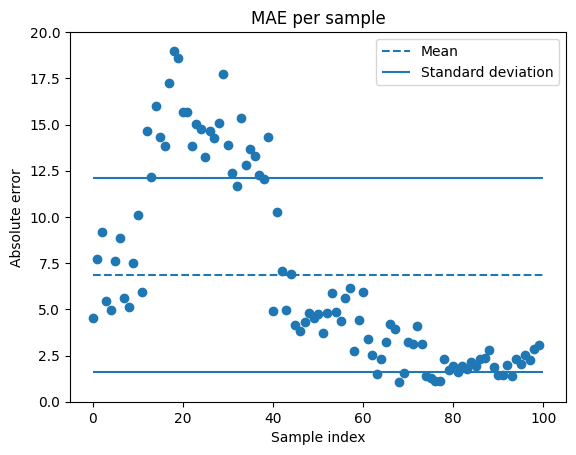

In [ ]:
seq_errors = np.mean(errors, axis=1)
print(seq_errors.shape)
x = np.arange(len(seq_errors))
seq_stds = np.std(seq_errors)
plt.scatter(x, seq_errors)
plt.hlines(seq_mean, 0, len(seq_errors), linestyles='dashed', label="Mean")
plt.hlines(seq_mean + seq_stds, 0, len(seq_errors), label='Standard deviation')
plt.hlines(seq_mean - seq_stds, 0, len(seq_errors))
plt.title("MAE per sample")
plt.xlabel("Sample index")
plt.ylim(0, 20)
plt.ylabel("Absolute error")
plt.legend()
plt.show()

### Learning Curve

In [ ]:
import os
import json

RUNS_DIR = "/content/drive/MyDrive/forecast_project_final/runs_gru"
BEST_DIR = os.path.join(RUNS_DIR, "BEST")

with open(os.path.join(BEST_DIR, "best_history.json"), "r") as f:
    hist = json.load(f)

print(hist.keys())

dict_keys(['train_loss', 'val_loss', 'train_mse', 'val_mse', 'train_mae', 'val_mae', 'train_mape', 'val_mape', 'lr'])


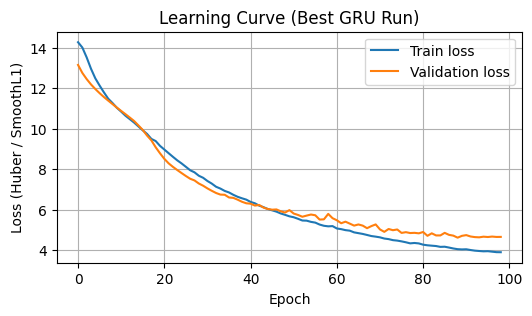

In [ ]:
plt.figure(figsize=(6,3))
plt.plot(hist["train_loss"], label="Train loss")
plt.plot(hist["val_loss"], label="Validation loss")
plt.title("Learning Curve (Best GRU Run)")
plt.xlabel("Epoch")
plt.ylabel("Loss (Huber / SmoothL1)")
plt.legend()
plt.grid(True)
plt.show()

Modell lernt kontinuierlich, kein instabiles Training, keine Divergenz, keine Explosion, kein starkes Overfitting

#### MAE Curve

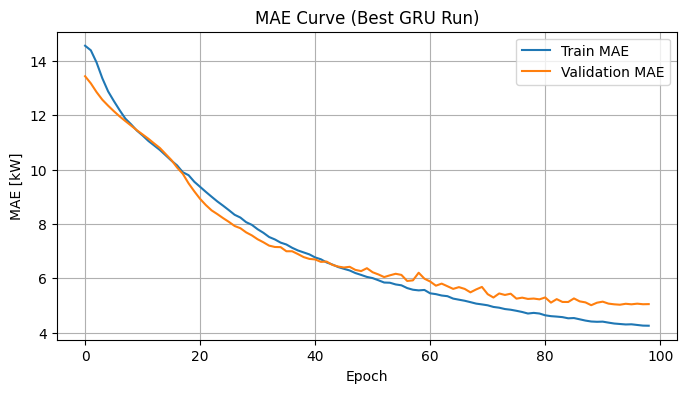

In [ ]:
plt.figure(figsize=(8,4))
plt.plot(hist["train_mae"], label="Train MAE")
plt.plot(hist["val_mae"], label="Validation MAE")
plt.title("MAE Curve (Best GRU Run)")
plt.xlabel("Epoch")
plt.ylabel("MAE [kW]")
plt.legend()
plt.grid(True)
plt.show()

Am Ende:
- Train MAE etwa 4.3kW
- Val MAE etwa 5.0kw

Durchschnittlicher 24h Forecast-Fehler liegt bei etwa 5 kW auf Validierungsdaten

- The learning curves show stable convergence
- Training and validation loss decrease steadily without divergence
- The small gap indicates good generalization
- No severe overfitting is observed


Modell unterschätzt hohe WErte, überschätzt niedrige Werte


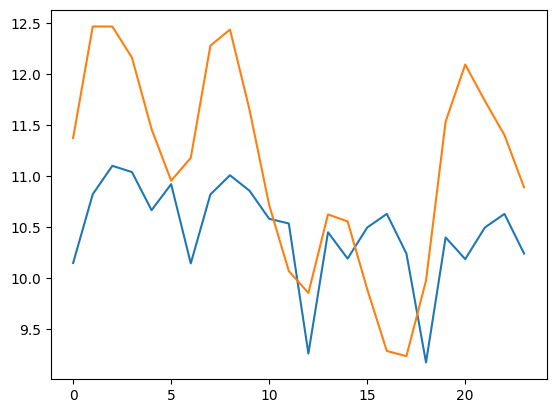

In [ ]:
plt.plot(y_test.mean(axis=0))
plt.plot(y_pred.mean(axis=0))

## Error Analysis

#### Einzelner 24h Forecast (True vs. Prediction)
The model captures the overall daily PV production pattern, including peak timing and general curve shape. However, systematic deviations are visible:

- Early morning production is overestimated.

- Peak amplitude is slightly underestimated.

- Nighttime values are not strictly zero and may even become negative.


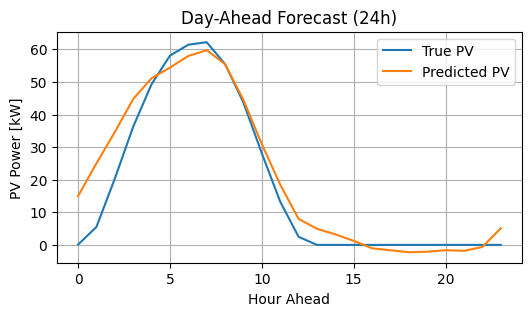

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

sample_id = 0

plt.figure(figsize=(6,3))
plt.plot(y_test[sample_id], label="True PV")
plt.plot(y_pred[sample_id], label="Predicted PV")
plt.title("Day-Ahead Forecast (24h)")
plt.xlabel("Hour Ahead")
plt.ylabel("PV Power [kW]")
plt.legend()
plt.grid(True)
plt.show()

#### More examples

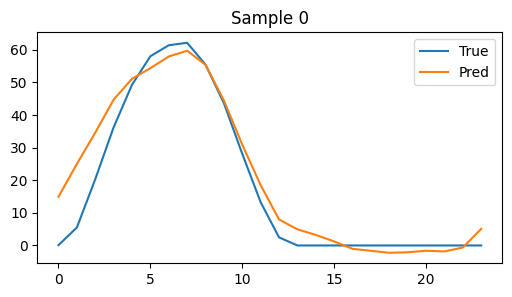

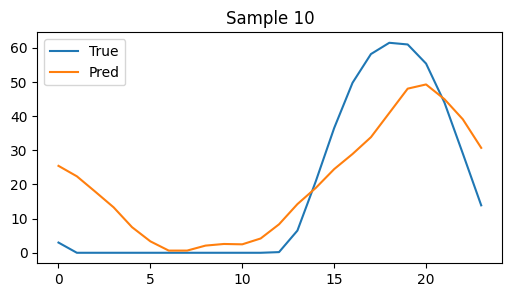

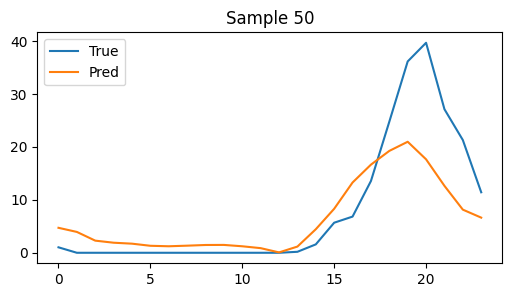

IndexError: index 100 is out of bounds for axis 0 with size 100

<Figure size 600x300 with 0 Axes>

In [ ]:
for i in [0, 10, 50, 100]:
    plt.figure(figsize=(6,3))
    plt.plot(y_test[i], label="True")
    plt.plot(y_pred[i], label="Pred")
    plt.title(f"Sample {i}")
    plt.legend()
    plt.show()

Individual forecast examples reveal systematic model behavior:

Nighttime production is overestimated.

Peak production is consistently underestimated.

The predicted curves are smoother than the true curves.

Rapid production increases are damped.

This confirms the regression-to-the-mean behavior observed in the average profile plot.
The model prioritizes minimizing overall loss rather than preserving peak amplitudes.

#### Average 24hour day in Testset
The average predicted 24h profile shows systematic deviations from the true mean profile. Instead of merely smoothing the signal, the model introduces horizon-dependent bias:

Early forecast hours tend to be overestimated.

Mid-day or late forecast hours show underestimation.

Bias patterns are consistent across the test set.

This indicates that the model has learned a distorted temporal structure

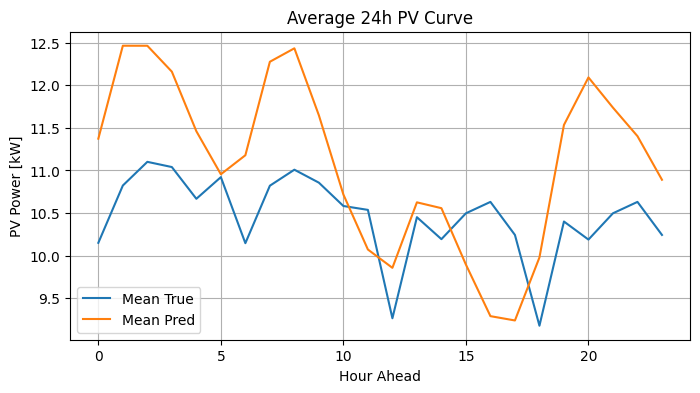

In [ ]:
mean_true = y_test.mean(axis=0)
mean_pred = y_pred.mean(axis=0)

plt.figure(figsize=(8,4))
plt.plot(mean_true, label="Mean True")
plt.plot(mean_pred, label="Mean Pred")
plt.title("Average 24h PV Curve")
plt.xlabel("Hour Ahead")
plt.ylabel("PV Power [kW]")
plt.legend()
plt.grid(True)
plt.show()

#### Which hours are under- or over estimated
- model learns verzerrte 24h structure

- Early forecast hours are consistently overestimated.

- Mid-horizon hours are underestimated.

- Late forecast hours show overestimation again.


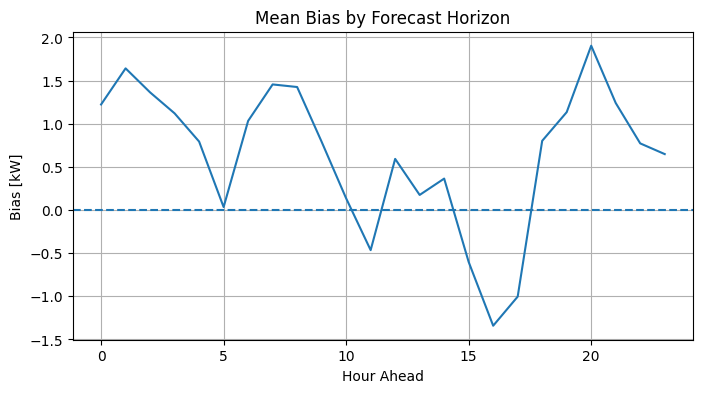

In [ ]:
bias = mean_pred - mean_true

plt.figure(figsize=(8,4))
plt.plot(bias)
plt.axhline(0, linestyle="--")
plt.title("Mean Bias by Forecast Horizon")
plt.xlabel("Hour Ahead")
plt.ylabel("Bias [kW]")
plt.grid(True)
plt.show()


#### Fehler pro Forecast-Hour

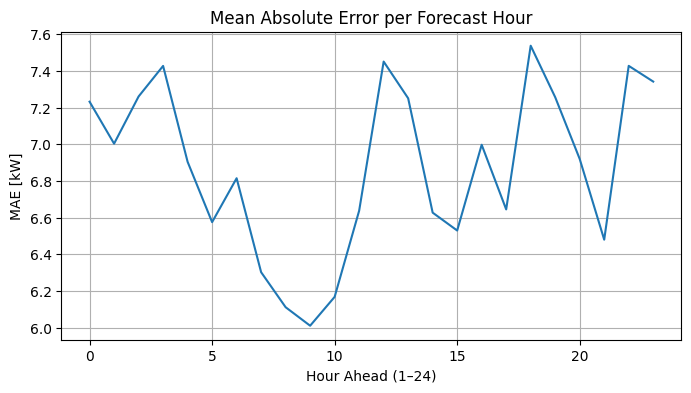

In [ ]:
abs_error = np.abs(y_pred - y_test)
mean_error_per_hour = abs_error.mean(axis=0)

plt.figure(figsize=(8,4))
plt.plot(mean_error_per_hour)
plt.title("Mean Absolute Error per Forecast Hour")
plt.xlabel("Hour Ahead (1–24)")
plt.ylabel("MAE [kW]")
plt.grid(True)
plt.show()

#### MAE by Forecast Horizon
The MAE is not uniform across the 24-hour forecast horizon.

Early forecast hours show elevated error.

Mid-horizon hours exhibit the lowest error.

Late forecast hours again show increased error.

This correlates directly with the previously observed horizon-dependent bias.

The findings suggest that the direct multi-output GRU struggles to maintain structural accuracy across the entire horizon, particularly at the beginning and end of the forecast window.

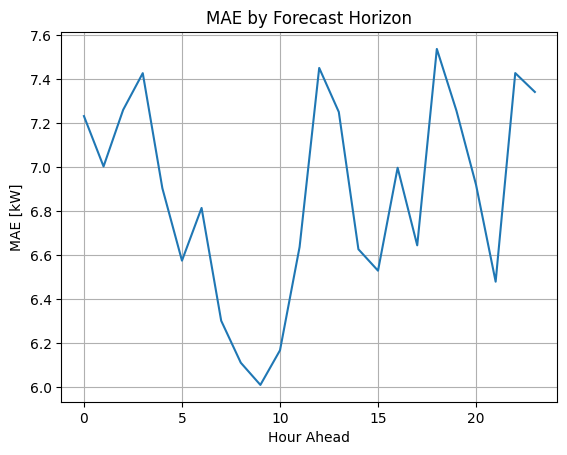

In [ ]:
mae_by_h = np.mean(np.abs(y_pred - y_test), axis=0)

plt.figure()
plt.plot(mae_by_h)
plt.title("MAE by Forecast Horizon")
plt.xlabel("Hour Ahead")
plt.ylabel("MAE [kW]")
plt.grid(True)
plt.show()

#### Error Distribution
- lot of hours have small error

However, a long heavy tail reveals occasional large forecast errors, particularly during peak production hours or rapid transitions.


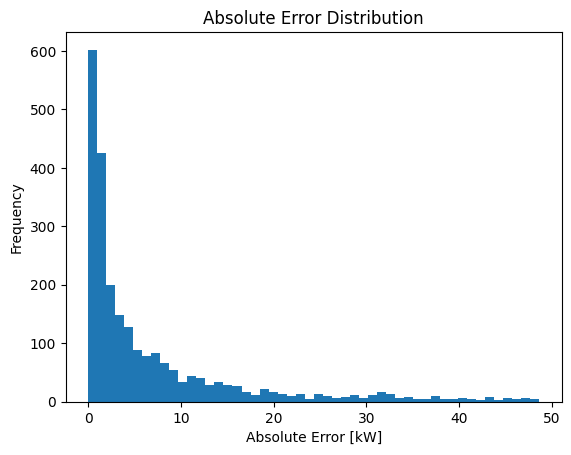

In [ ]:
plt.hist(abs_error.flatten(), bins=50)
plt.title("Absolute Error Distribution")
plt.xlabel("Absolute Error [kW]")
plt.ylabel("Frequency")
plt.show()

#### Error Night vs. Day
Separating the absolute errors into daytime and nighttime periods reveals a clear structural pattern:

Nighttime errors are small and tightly distributed.

Daytime errors show a broad distribution with a heavy tail.

This confirms that the model’s main weakness lies in high-production periods, particularly around peak hours. The model systematically underestimates high PV outputs, leading to large absolute errors during daytime, while nighttime predictions contribute minimally to the overall MAE

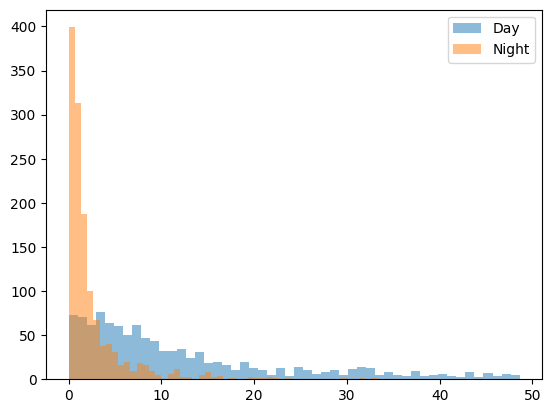

In [ ]:
is_day = y_test.flatten() > 1  # z.B. >1 kW als Tag
day_errors = abs_error.flatten()[is_day]
night_errors = abs_error.flatten()[~is_day]

plt.hist(day_errors, bins=50, alpha=0.5, label="Day")
plt.hist(night_errors, bins=50, alpha=0.5, label="Night")
plt.legend()
plt.show()

#### Scatter Plot (Prediction vs True)
- Kleine Werte werden überschätzt

- Große Werte werden unterschätzt

The scatter plot of predicted versus true values reveals a clear regression-to-the-mean behavior:

- Low PV values are systematically overestimated.

- High PV values are consistently underestimated.

- Variance increases with production level (heteroskedastic error).

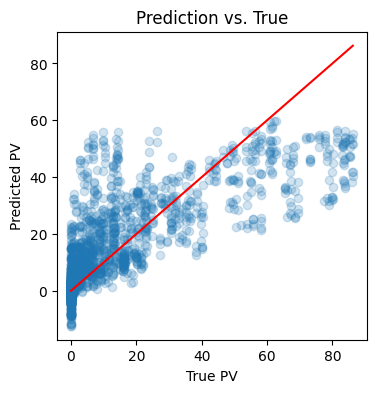

In [ ]:
plt.figure(figsize=(4,4))
plt.scatter(y_test.flatten(), y_pred.flatten(), alpha=0.2)
plt.xlabel("True PV")
plt.ylabel("Predicted PV")
plt.plot([0, max(y_test.flatten())],
         [0, max(y_test.flatten())],
         'r')
plt.title("Prediction vs. True")
plt.show()

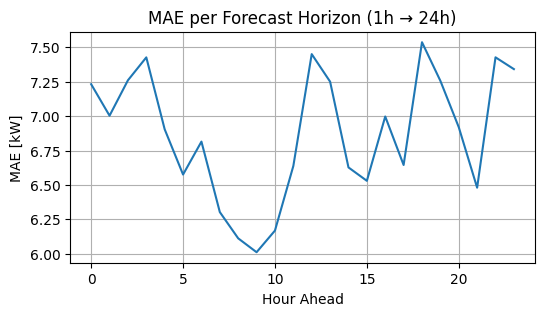

In [ ]:
abs_error = np.abs(y_pred - y_test)
mae_per_hour = abs_error.mean(axis=0)

plt.figure(figsize=(6,3))
plt.plot(mae_per_hour)
plt.title("MAE per Forecast Horizon (1h → 24h)")
plt.xlabel("Hour Ahead")
plt.ylabel("MAE [kW]")
plt.grid(True)
plt.show()

#### Fehler nur bei Tagesstunden

In [ ]:
mask = y_test > 1
day_mae = np.mean(np.abs(y_pred[mask] - y_test[mask]))
print("Daytime MAE:", day_mae)


Daytime MAE: 12.299579312341658


#### Fehler bei Peak-Leistung

In [ ]:
peak_mask = y_test > (0.8 * y_test.max())
peak_mae = np.mean(np.abs(y_pred[peak_mask] - y_test[peak_mask]))
print("Peak MAE:", peak_mae)

Peak MAE: 34.30895611564396


#### Bias Analysis

In [ ]:
bias = (y_pred - y_test).mean()
print("Mean Bias:", bias)

Mean Bias: 0.6343922732772641


#### Fehler nach Saison

#### Worst Case vs. Best Case

In [ ]:
sample_errors = np.abs(y_pred - y_test).mean(axis=1)

best_id = np.argmin(sample_errors)
worst_id = np.argmax(sample_errors)
#plot this as well

#### Fehler cs. Cloud Cover

### Prediction Plots
Einzelne 24h-Tage: True vs Pred
- 5 random Test samples + 2 schwierige

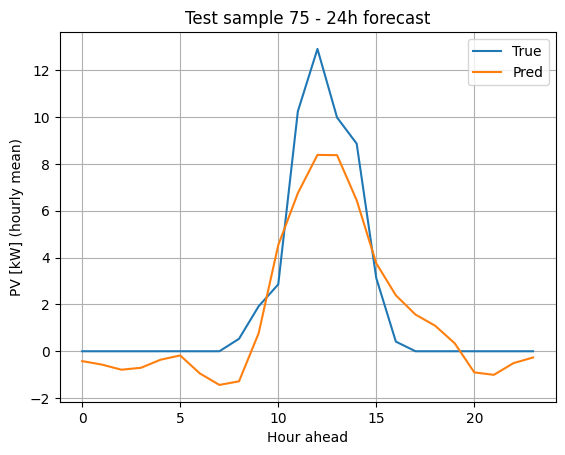

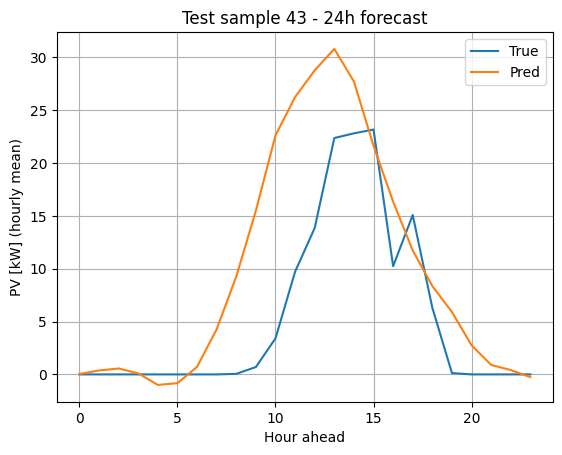

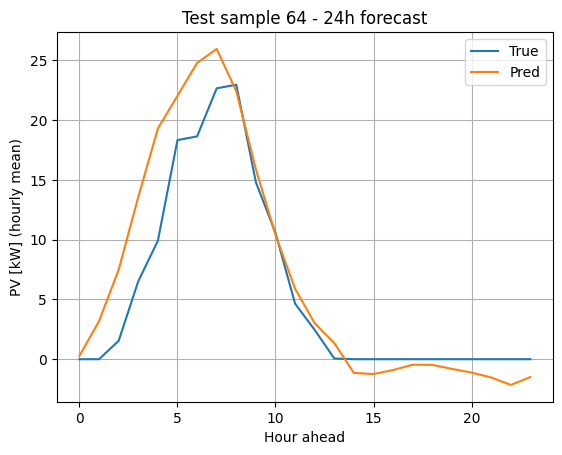

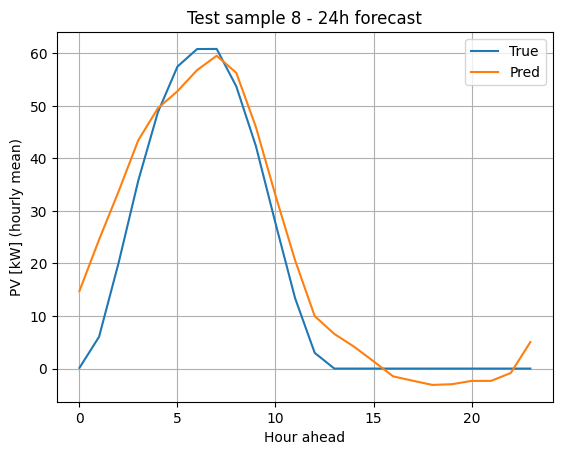

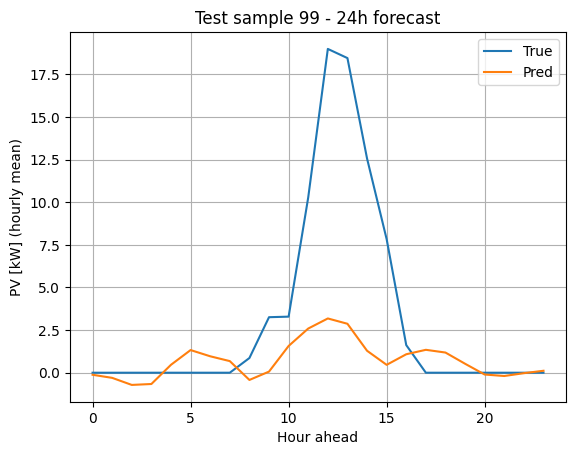

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

rng = np.random.default_rng(42)
idxs = rng.choice(len(y_test), size=5, replace=False)

for i, ix in enumerate(idxs, 1):
    plt.figure()
    plt.plot(y_test[ix], label="True")
    plt.plot(y_pred[ix], label="Pred")
    plt.title(f"Test sample {ix} - 24h forecast")
    plt.xlabel("Hour ahead")
    plt.ylabel("PV [kW] (hourly mean)")
    plt.grid(True)
    plt.legend()
    plt.show()

#### Show Best, Median, Worst

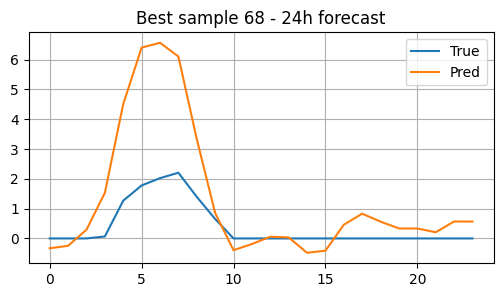

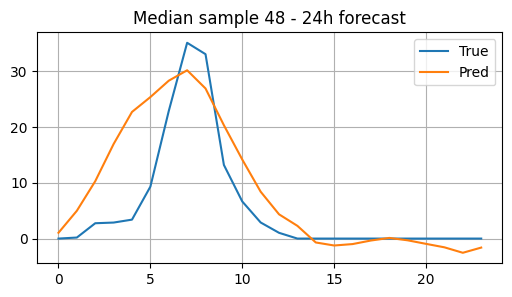

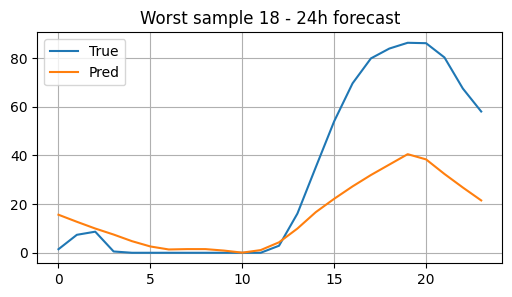

In [ ]:
abs_err_per_sample = np.mean(np.abs(y_pred - y_test), axis=1)  # (N,)
best = np.argmin(abs_err_per_sample)
median = np.argsort(abs_err_per_sample)[len(abs_err_per_sample)//2]
worst = np.argmax(abs_err_per_sample)

for ix, name in [(best,"Best"), (median,"Median"), (worst,"Worst")]:
    plt.figure(figsize=(6,3))
    plt.plot(y_test[ix], label="True")
    plt.plot(y_pred[ix], label="Pred")
    plt.title(f"{name} sample {ix} - 24h forecast")
    plt.grid(True); plt.legend(); plt.show()

#### Durchschnitt über alle Test samples!


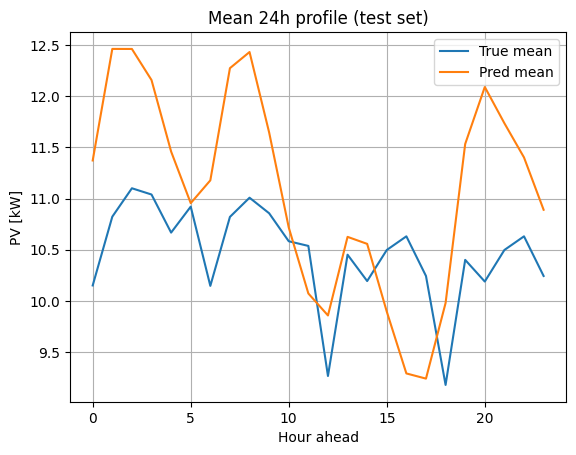

In [ ]:
plt.figure()
plt.plot(y_test.mean(axis=0), label="True mean")
plt.plot(y_pred.mean(axis=0), label="Pred mean")
plt.title("Mean 24h profile (test set)")
plt.xlabel("Hour ahead")
plt.ylabel("PV [kW]")
plt.grid(True)
plt.legend()
plt.show()
